(alpha=0.5, gamma=0.5) -> (Max E(gi): 0.9973, Max H(gi): 0.9939) | Utility: -0.3437
(alpha=0.5, gamma=0.5) -> (Min E(gi): 0.0001, Min H(gi): 0.0004) | Utility: 0.0000
(alpha=0.5, gamma=0.5) -> (Avg E(gi): 0.4909, Avg H(gi): 0.5270) | Utility: -0.0522
(alpha=0.5, gamma=0.5) -> (Mid E(gi): 0.5359, Mid H(gi): 0.5440) | Utility: -0.0548

(alpha=0.5, gamma=0.5) -> (High E, Low H): E=0.9973, H=0.0004 | Utility: 0.1502
(alpha=0.5, gamma=0.5) -> (High E, High H): E=0.9973, H=0.9939 | Utility: -0.3437
(alpha=0.5, gamma=0.5) -> (Low E, Low H): E=0.0001, H=0.0004 | Utility: 0.0000
(alpha=0.5, gamma=0.5) -> (Low E, High H): E=0.0001, H=0.9939 | Utility: -0.4939
(alpha=0.5, gamma=0.5) -> (Random idx 168): E=0.6063, H=0.3665 | Utility: 0.0357

(alpha=0.5, gamma=1.0) -> (Max E(gi): 0.9968, Max H(gi): 0.9893) | Utility: -0.8286
(alpha=0.5, gamma=1.0) -> (Min E(gi): 0.0030, Min H(gi): 0.0031) | Utility: 0.0006
(alpha=0.5, gamma=1.0) -> (Avg E(gi): 0.4889, Avg H(gi): 0.5092) | Utility: -0.1729
(alpha=0.

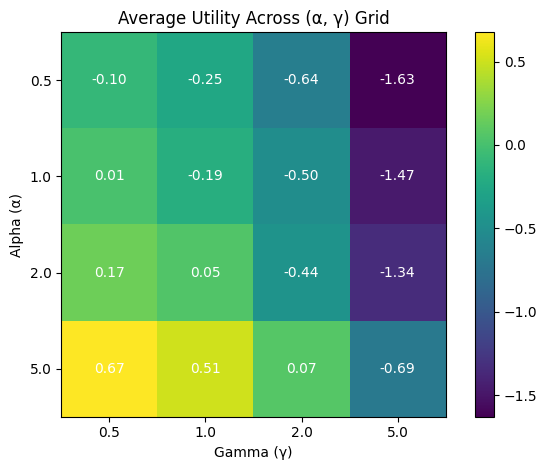

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Simulated engagement (E) and harm (H) scores for a set of responses (gi)
np.random.seed(1)
num_samples = 207

# Define utility function
def utility_function(E, H, alpha, gamma):
    E = np.array(E)
    H = np.array(H)
    return alpha * np.log10(1+E) - gamma * (H ** 2)

# Grid of (alpha, gamma) values to test
alpha_values = [0.5, 1.0, 2.0, 5.0]
gamma_values = [0.5, 1.0, 2.0, 5.0]

# Store average utility for each (alpha, gamma) pair
results = np.zeros((len(alpha_values), len(gamma_values)))

# Evaluate utility across the grid
for i, alpha in enumerate(alpha_values):
    for j, gamma in enumerate(gamma_values):
        engagement_scores = np.random.uniform(0, 1, num_samples)
        harm_scores = np.random.uniform(0, 1, num_samples)
        utilities = utility_function(engagement_scores, harm_scores, alpha, gamma)
        avg_utility = np.mean(utilities)
        # --- Engagement statistics ---
        eng_max = np.max(engagement_scores)
        eng_min = np.min(engagement_scores)
        eng_mean = np.mean(engagement_scores)
        eng_median = np.median(engagement_scores)

        # eng_max_idx = np.argmax(engagement_scores)
        # eng_min_idx = np.argmin(engagement_scores)
        # eng_median_idx = np.argsort(engagement_scores)[len(engagement_scores)//2]

        # --- Harm statistics ---
        harm_max = np.max(harm_scores)
        harm_min = np.min(harm_scores)
        harm_mean = np.mean(harm_scores)
        harm_median = np.median(harm_scores)

        # harm_max_idx = np.argmax(harm_scores)
        # harm_min_idx = np.argmin(harm_scores)
        # harm_median_idx = np.argsort(harm_scores)[len(harm_scores)//2]
        results[i, j] = avg_utility

        util_max = utility_function([eng_max], [harm_max], alpha, gamma)[0]
        util_min = utility_function([eng_min], [harm_min], alpha, gamma)[0]
        util_mean = utility_function([eng_mean], [harm_mean], alpha, gamma)[0]
        util_median = utility_function([eng_median], [harm_median], alpha, gamma)[0]

        print(f"(alpha={alpha}, gamma={gamma}) -> (Max E(gi): {eng_max:.4f}, Max H(gi): {harm_max:.4f}) | Utility: {util_max:.4f}")
        print(f"(alpha={alpha}, gamma={gamma}) -> (Min E(gi): {eng_min:.4f}, Min H(gi): {harm_min:.4f}) | Utility: {util_min:.4f}")
        print(f"(alpha={alpha}, gamma={gamma}) -> (Avg E(gi): {eng_mean:.4f}, Avg H(gi): {harm_mean:.4f}) | Utility: {util_mean:.4f}")
        print(f"(alpha={alpha}, gamma={gamma}) -> (Mid E(gi): {eng_median:.4f}, Mid H(gi): {harm_median:.4f}) | Utility: {util_median:.4f}\n")

        # Additional combinations
        util_hi_eng_lo_harm = utility_function(eng_max, harm_min, alpha, gamma)
        util_hi_eng_hi_harm = utility_function(eng_max, harm_max, alpha, gamma)
        util_lo_eng_lo_harm = utility_function(eng_min, harm_min, alpha, gamma)
        util_lo_eng_hi_harm = utility_function(eng_min, harm_max, alpha, gamma)

        # Random index example
        rand_idx = np.random.randint(0, num_samples)
        util_random = utility_function(engagement_scores[rand_idx], harm_scores[rand_idx], alpha, gamma)

        print(f"(alpha={alpha}, gamma={gamma}) -> (High E, Low H): E={eng_max:.4f}, H={harm_min:.4f} | Utility: {util_hi_eng_lo_harm:.4f}")
        print(f"(alpha={alpha}, gamma={gamma}) -> (High E, High H): E={eng_max:.4f}, H={harm_max:.4f} | Utility: {util_hi_eng_hi_harm:.4f}")
        print(f"(alpha={alpha}, gamma={gamma}) -> (Low E, Low H): E={eng_min:.4f}, H={harm_min:.4f} | Utility: {util_lo_eng_lo_harm:.4f}")
        print(f"(alpha={alpha}, gamma={gamma}) -> (Low E, High H): E={eng_min:.4f}, H={harm_max:.4f} | Utility: {util_lo_eng_hi_harm:.4f}")
        print(f"(alpha={alpha}, gamma={gamma}) -> (Random idx {rand_idx}): E={engagement_scores[rand_idx]:.4f}, H={harm_scores[rand_idx]:.4f} | Utility: {util_random:.4f}\n")

# Plotting the utility landscape
fig, ax = plt.subplots()
im = ax.imshow(results, cmap='viridis')

# Set ticks and labels
ax.set_xticks(np.arange(len(gamma_values)))
ax.set_yticks(np.arange(len(alpha_values)))
ax.set_xticklabels(gamma_values)
ax.set_yticklabels(alpha_values)
ax.set_xlabel("Gamma (γ)")
ax.set_ylabel("Alpha (α)")
ax.set_title("Average Utility Across (α, γ) Grid")

# Annotate each cell with utility value
for i in range(len(alpha_values)):
    for j in range(len(gamma_values)):
        text = ax.text(j, i, f"{results[i, j]:.2f}",
                       ha="center", va="center", color="w")

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

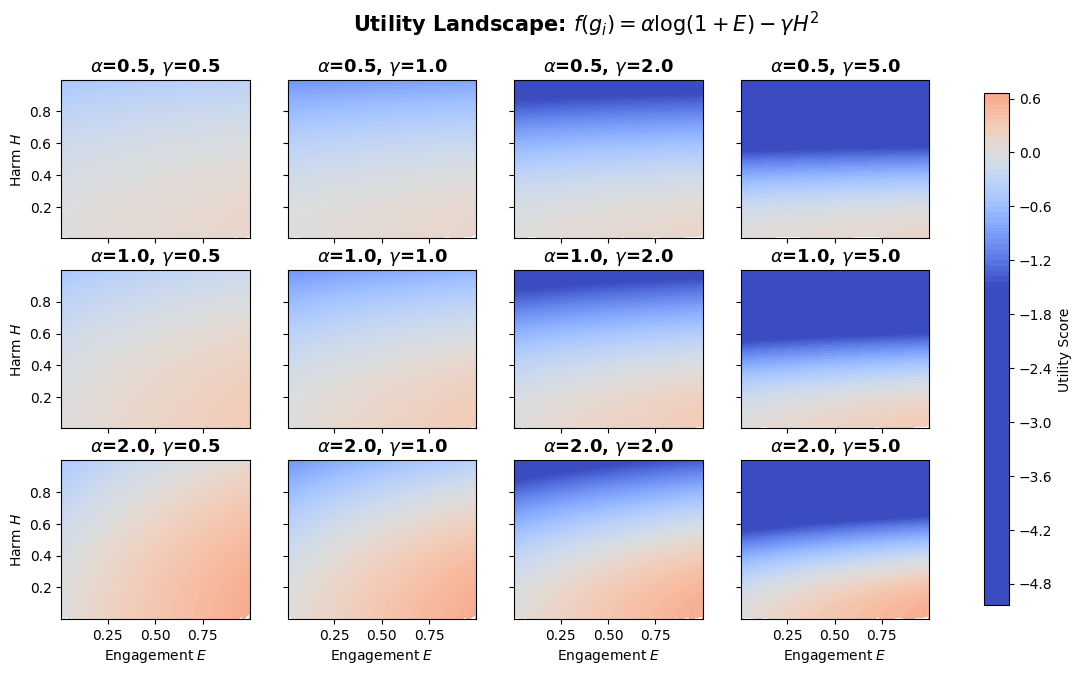

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Setup
np.random.seed(42)
num_samples = 1000

# Simulated scores
engagement_scores = np.random.uniform(0, 1, num_samples)
harm_scores = np.random.uniform(0, 1, num_samples)

# Define utility function
def utility_function(E, H, alpha, gamma):
    return alpha * np.log10(1 + E) - gamma * (H ** 2)

# Define α and γ values for grid search
alpha_list = [0.5, 1.0, 2.0]
gamma_list = [0.5, 1.0, 2.0, 5.0]

# Create meshgrid of all possible (E, H) pairs
E_vals, H_vals = np.meshgrid(engagement_scores, harm_scores)

# Compute shape info
nrows, ncols = len(alpha_list), len(gamma_list)
fig, axs = plt.subplots(nrows, ncols, figsize=(14, 7), sharex=True, sharey=True)
fig.suptitle(r"Utility Landscape: $f(g_i) = \alpha \log(1 + E) - \gamma H^2$", fontsize=15, fontweight='bold')

# Define color limits for consistency
vmin = -1.5
vmax = 1.5

# Plot each (α, γ) utility surface
for i, alpha in enumerate(alpha_list):
    for j, gamma in enumerate(gamma_list):
        ax = axs[i, j]
        Z = utility_function(E_vals, H_vals, alpha, gamma)

        # Plot the contour
        contour = ax.contourf(E_vals, H_vals, Z, levels=100, cmap='coolwarm', vmin=vmin, vmax=vmax)
        ax.set_title(rf"$\alpha$={alpha}, $\gamma$={gamma}", fontsize=13, fontweight='bold')

        # Set axis labels
        if i == nrows - 1:
            ax.set_xlabel("Engagement $E$")
        if j == 0:
            ax.set_ylabel("Harm $H$")

# Add shared colorbar
cbar = fig.colorbar(contour, ax=axs, orientation='vertical', shrink=0.95, label="Utility Score")
# plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


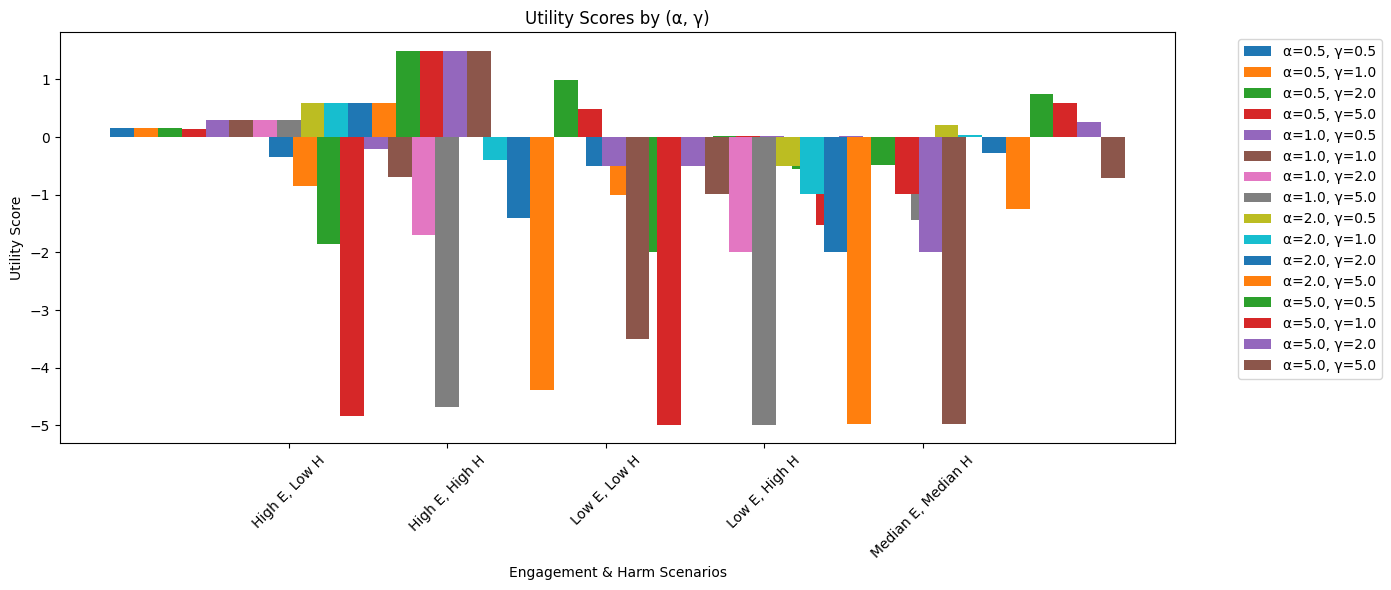

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Plot type: choose from 'bar', 'line', or 'heatmap'
plot_type = 'bar'  # change this to 'line' or 'heatmap' as needed

# Setup
np.random.seed(0)
num_samples = 107
alpha_values = [0.5, 1.0, 2.0, 5.0]
gamma_values = [0.5, 1.0, 2.0, 5.0]

# Define utility function
def utility_function(E, H, alpha, gamma):
    return alpha * np.log10(1 + E) - gamma * (H ** 2)

# Define key (E, H) combinations
def get_combinations(E_scores, H_scores):
    return {
        "High E, Low H": (np.max(E_scores), np.min(H_scores)),
        "High E, High H": (np.max(E_scores), np.max(H_scores)),
        "Low E, Low H": (np.min(E_scores), np.min(H_scores)),
        "Low E, High H": (np.min(E_scores), np.max(H_scores)),
        # "Mean E, Mean H": (np.mean(E_scores), np.mean(H_scores)),
        "Median E, Median H": (np.median(E_scores), np.median(H_scores))
    }

# Prepare storage for utilities
comb_labels = list(get_combinations(np.zeros(num_samples), np.zeros(num_samples)).keys())
num_combinations = len(comb_labels)
utility_data = {}

E_scores = np.random.uniform(0, 1, num_samples)
H_scores = np.random.uniform(0, 1, num_samples)
combinations = get_combinations(E_scores, H_scores)

# Generate data and compute utilities
for alpha in alpha_values:
    for gamma in gamma_values:
        utilities = [utility_function(E, H, alpha, gamma) for (E, H) in combinations.values()]
        utility_data[(alpha, gamma)] = utilities

# Plotting
if plot_type == 'bar':
    fig, ax = plt.subplots(figsize=(14, 6))
    x = np.arange(num_combinations)
    width = 0.15
    offset = 0

    for (alpha, gamma), utilities in utility_data.items():
        ax.bar(x + offset, utilities, width=width, label=f"α={alpha}, γ={gamma}")
        offset += width

    ax.set_xlabel('Engagement & Harm Scenarios')
    ax.set_ylabel('Utility Score')
    ax.set_title('Utility Scores by (α, γ)')
    ax.set_xticks(x + width * (len(utility_data)) / 2 - width)
    ax.set_xticklabels(comb_labels, rotation=45)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()

elif plot_type == 'line':
    fig, ax = plt.subplots(figsize=(14, 6))
    x = np.arange(num_combinations)

    for (alpha, gamma), utilities in utility_data.items():
        ax.plot(x, utilities, marker='o', label=f"α={alpha}, γ={gamma}")

    ax.set_xticks(x)
    ax.set_xticklabels(comb_labels, rotation=45)
    ax.set_xlabel('Engagement & Harm Scenarios')
    ax.set_ylabel('Utility Score')
    ax.set_title('Line Plot of Utility Scores by (α, γ)')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()

elif plot_type == 'heatmap':
    for label_idx, label in enumerate(comb_labels):
        fig, ax = plt.subplots()
        heatmap = np.zeros((len(alpha_values), len(gamma_values)))
        for i, alpha in enumerate(alpha_values):
            for j, gamma in enumerate(gamma_values):
                heatmap[i, j] = utility_data[(alpha, gamma)][label_idx]

        cax = ax.imshow(heatmap, cmap='coolwarm')
        ax.set_xticks(np.arange(len(gamma_values)))
        ax.set_yticks(np.arange(len(alpha_values)))
        ax.set_xticklabels(gamma_values)
        ax.set_yticklabels(alpha_values)
        ax.set_xlabel('γ')
        ax.set_ylabel('α')
        ax.set_title(f'Utility Heatmap: {label}')
        for i in range(len(alpha_values)):
            for j in range(len(gamma_values)):
                ax.text(j, i, f"{heatmap[i, j]:.2f}", ha="center", va="center", color="black")
        fig.colorbar(cax, ax=ax)
        plt.tight_layout()

plt.show()


In [ ]:
import csv

# CSV output file name
csv_filename = "ai-in-the-loop/results/utility_scores_by_alpha_gamma.csv"

# Header row for CSV
csv_header = ["alpha", "gamma"] + comb_labels

# Write to CSV
with open(csv_filename, mode='w', newline='') as file:
    writer = csv.writer(file)
    writer.writerow(csv_header)

    for (alpha, gamma), utilities in utility_data.items():
        writer.writerow([alpha, gamma] + utilities)

print(f"\n✅ Utility scores saved to '{csv_filename}' successfully.")


In [ ]:
import numpy as np
import pandas as pd

# Set seed for reproducibility
np.random.seed(42)

# Number of simulated samples
num_samples = 100

# Define hyperparameter values
alpha_values = [0.5, 1.0, 2.0, 5.0]
gamma_values = [0.5, 1.0, 2.0, 5.0]

# Define utility function
def utility_function(E, H, alpha, gamma):
    return alpha * np.log10(1 + E) - gamma * (H ** 2)

# Define key E and H scenarios
def get_scenarios(E_scores, H_scores):
    return {
        "High E, Low H": (np.max(E_scores), np.min(H_scores)),
        "High E, High H": (np.max(E_scores), np.max(H_scores)),
        "Low E, Low H": (np.min(E_scores), np.min(H_scores)),
        "Low E, High H": (np.min(E_scores), np.max(H_scores)),
        "Mean E, Mean H": (np.mean(E_scores), np.mean(H_scores)),
        "Median E, Median H": (np.median(E_scores), np.median(H_scores))
    }

# Simulate engagement and harm scores
E_scores = np.random.uniform(0, 1, num_samples)
H_scores = np.random.uniform(0, 1, num_samples)

# Get representative scenarios
scenarios = get_scenarios(E_scores, H_scores)
# Initialize list to collect records
records = []

# Generate combinations and compute utility
for alpha in alpha_values:
    for gamma in gamma_values:
        
        for label, (E, H) in scenarios.items():
            utility = utility_function(E, H, alpha, gamma)
            records.append({
                "Alpha": alpha,
                "Gamma": gamma,
                "Scenario": label,
                "E Value": E,
                "H Value": H,
                "Utility Score": utility
            })

# Convert to DataFrame
df = pd.DataFrame(records)

# Save to CSV
df.to_csv("ai-in-the-loop/results/utility_scores_by_alpha_gamma.csv", index=False)
print("CSV file 'utility_scores_by_alpha_gamma.csv' has been generated.")


CSV file 'utility_scores_by_alpha_gamma.csv' has been generated.


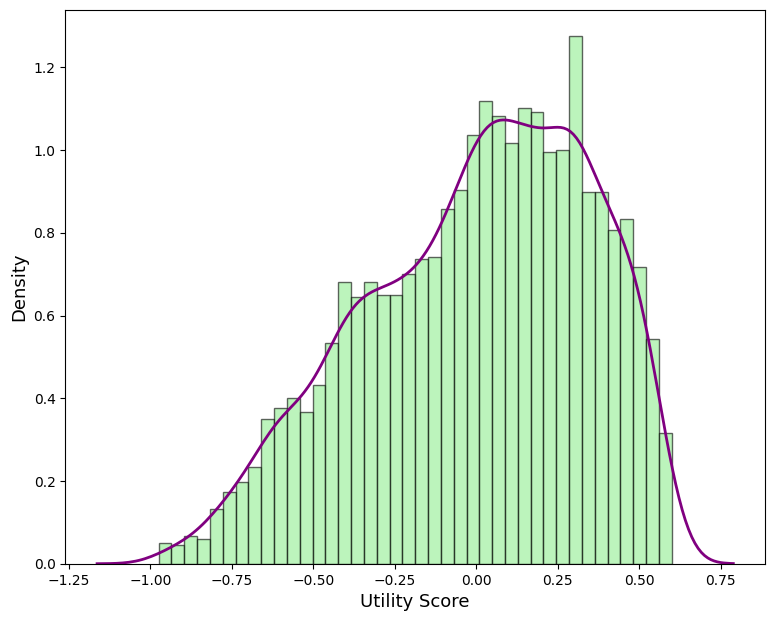

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Parameters
alpha = 2.0
gamma = 1.0
num_samples = 5000

# Generate random E and H values in [0, 1]
E = np.random.uniform(0, 1, num_samples)
H = np.random.uniform(0, 1, num_samples)


# Utility function using log base 10
def utility(E, H, alpha, gamma):
    return alpha * np.log10(1 + E) - gamma * H**2

# Compute utility scores
utility_scores = utility(E, H, alpha, gamma)

# Set up plotting layout
plt.figure(figsize=(15, 12))

# Plot 1: Histogram
# plt.subplot(2, 2, 1)
# plt.hist(utility_scores, bins=40, color='skyblue', edgecolor='black')
# plt.title('Histogram of Utility Scores')
# plt.xlabel('Utility Score')
# plt.ylabel('Frequency')

# Plot 1: Histogram with KDE overlay
# Plot 1: Histogram and KDE with different colors
plt.subplot(2, 2, 1)
# Histogram in skyblue
plt.hist(utility_scores, bins=40, color='lightgreen', edgecolor='black', alpha=0.6, density=True, label='Histogram')
# KDE in purple
sns.kdeplot(utility_scores, color='purple', linewidth=2, label='KDE')
# plt.title('Histogram and KDE of Utility Scores')
plt.xlabel('Utility Score', fontsize=13)
plt.ylabel('Density', fontsize=13)

# Plot 2: Scatter plot (E vs H, colored by utility)
# plt.subplot(2, 2, 2)
# sc = plt.scatter(E, H, c=utility_scores, cmap='coolwarm', s=20, edgecolor='k')
# plt.colorbar(sc, label='Utility Score')
# plt.title('Scatter Plot of E vs. H Colored by Utility')
# plt.xlabel('Engagement (E)')
# plt.ylabel('Harm (H)')

# # Plot 3: Boxplot
# plt.subplot(2, 2, 3)
# sns.boxplot(y=utility_scores, color='lightgreen')
# plt.title('Boxplot of Utility Scores')
# plt.ylabel('Utility Score')

# # Plot 4: KDE Plot
# plt.subplot(2, 2, 4)
# sns.kdeplot(utility_scores, fill=True, color='purple')
# plt.title('KDE of Utility Scores')
# plt.xlabel('Utility Score')
# plt.ylabel('Density')


plt.tight_layout()
plt.show()

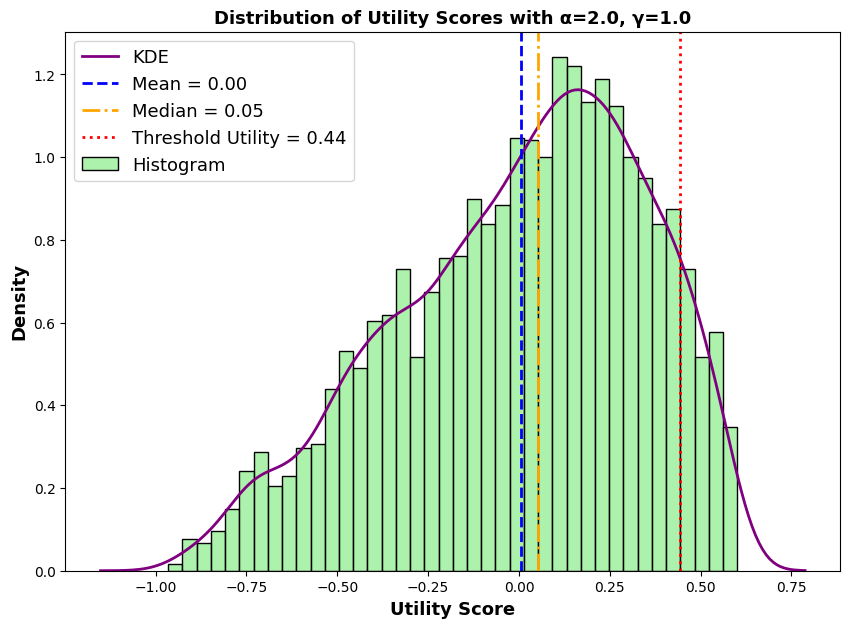

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Parameters
alpha = 2.0
gamma = 1.0
num_samples = 5000
harm_threshold = 0.4  # Example threshold

# Generate random E and H values in [0, 1]
E = np.random.uniform(0, 1, num_samples)
H = np.random.uniform(0, 1, num_samples)

# Utility function using log base 10
def utility(E, H, alpha, gamma):
    return alpha * np.log10(1 + E) - gamma * H**2

# Compute utility scores
utility_scores = utility(E, H, alpha, gamma)

# Calculate mean, median, and threshold-based reference
mean_utility = np.mean(utility_scores)
median_utility = np.median(utility_scores)
threshold_cutoff = alpha * np.log10(1 + 1.0) - gamma * (harm_threshold ** 2)  # Max E, harm threshold H

# Set up plot
plt.figure(figsize=(10, 7))

# Histogram and KDE
sns.histplot(utility_scores, bins=40, color='lightgreen', edgecolor='black', stat='density', label='Histogram')
sns.kdeplot(utility_scores, color='purple', linewidth=2, label='KDE')

# Vertical lines
plt.axvline(mean_utility, color='blue', linestyle='--', linewidth=2, label=f'Mean = {mean_utility:.2f}')
plt.axvline(median_utility, color='orange', linestyle='-.', linewidth=2, label=f'Median = {median_utility:.2f}')
plt.axvline(threshold_cutoff, color='red', linestyle=':', linewidth=2, label=f'Threshold Utility = {threshold_cutoff:.2f}')

# Labels and legend
plt.xlabel('Utility Score', fontsize=13, fontweight="bold")
plt.ylabel('Density', fontsize=13, fontweight="bold")
plt.title('Distribution of Utility Scores with α=2.0, γ=1.0', fontsize=13, fontweight="bold")
plt.legend(fontsize=13)
# plt.grid(True)
# plt.tight_layout()
plt.show()


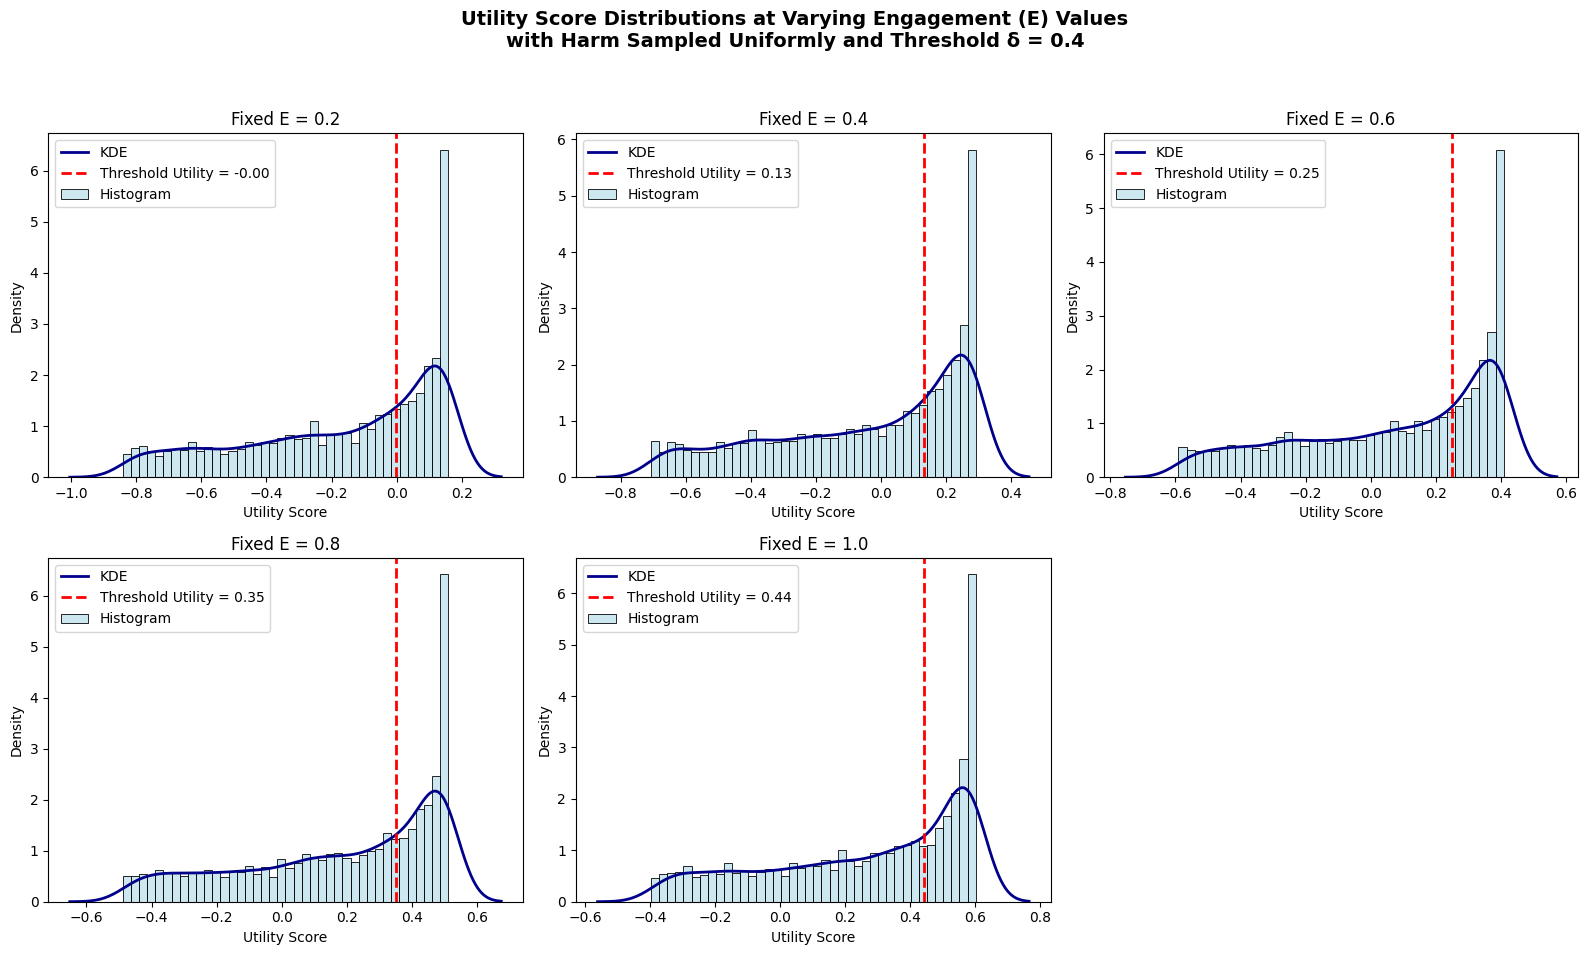

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Parameters
alpha = 2.0
gamma = 1.0
num_samples = 5000
harm_threshold = 0.4  # Harm threshold δ
E_values = [0.2, 0.4, 0.6, 0.8, 1.0]  # Fixed engagement values

# Utility function using log base 10
def utility(E, H, alpha, gamma):
    return alpha * np.log10(1 + E) - gamma * H**2

# Set up plot grid
plt.figure(figsize=(16, 10))
for i, fixed_E in enumerate(E_values, 1):
    # Generate random harm values
    H = np.random.uniform(0, 1, num_samples)
    E = np.full_like(H, fixed_E)  # Fixed E

    # Compute utility scores
    utility_scores = utility(E, H, alpha, gamma)

    # Threshold utility score for this E and harm threshold
    threshold_utility = alpha * np.log10(1 + fixed_E) - gamma * harm_threshold**2

    # Plot
    plt.subplot(2, 3, i)
    sns.histplot(utility_scores, bins=40, color='lightblue', stat='density', label='Histogram', alpha=0.6)
    sns.kdeplot(utility_scores, color='darkblue', linewidth=2, label='KDE')
    plt.axvline(threshold_utility, color='red', linestyle='--', linewidth=2,
                label=f'Threshold Utility = {threshold_utility:.2f}')
    plt.title(f'Fixed E = {fixed_E}', fontsize=12)
    plt.xlabel('Utility Score')
    plt.ylabel('Density')
    plt.legend()

# Remove empty subplot if number of E_values < subplot slots
if len(E_values) < 6:
    plt.subplot(2, 3, 6).axis('off')

plt.suptitle('Utility Score Distributions at Varying Engagement (E) Values\nwith Harm Sampled Uniformly and Threshold δ = 0.4',
             fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


In [ ]:
# # Pseudocode to optimize decoding parameters
# decoding_configs = [
#     {'temperature': 0.3, 'top_p': 0.8},
#     {'temperature': 0.7, 'top_p': 0.9},
#     {'temperature': 1.0, 'top_p': 0.95},
#     ...
# ]

# best_utility = -np.inf
# best_config = None

# for config in decoding_configs:
#     responses = generate_responses_with_config(config)
#     scores = [score_response(r) for r in responses]  # returns E, H
#     utilities = [utility(E, H, alpha=2.0, gamma=1.0) for E, H in scores]
#     avg_utility = np.mean(utilities)
    
#     if avg_utility > best_utility:
#         best_utility = avg_utility
#         best_config = config

# print("Best config:", best_config)
